In [ ]:
# --- SETUP ---
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display as lplt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#environment setup
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import random
import plotly.express as px
import plotly.figure_factory as ff
import zipfile


# --- RANDOM SEED ---
seed = 12
np.random.seed(seed)
#If you don’t set a seed, every time you run the code, results will differ slightly.

In [ ]:
# --- MOUNT GOOGLE DRIVE ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- EXTRACT DATASET ---
zip_path = '/content/drive/MyDrive/DATASET/GTZAN/Dataset.zip'
extract_path = '/content/GTZAN'

In [ ]:
if not os.path.exists(extract_path):
    print("Extracting dataset... ⏳")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction done ✅")

Extracting dataset... ⏳
Extraction done ✅


In [ ]:
# --- READ THE CSV ---
csv_path = os.path.join(extract_path, 'Data', 'features_3_sec.csv')
df = pd.read_csv(csv_path)
print("✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
df.head()

✅ Dataset loaded successfully!
Shape of dataset: (9990, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


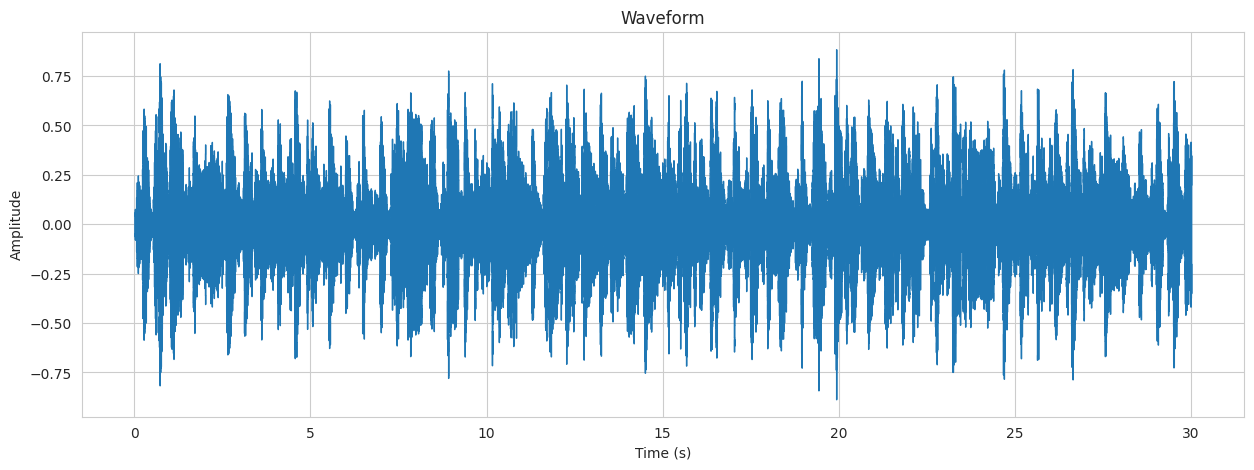

In [ ]:
# --- WAVEFORM DEMO ---
audio_path = os.path.join(extract_path, 'Data', 'genres_original', 'blues', 'blues.00000.wav')
audio_data, sr = librosa.load(audio_path, sr=None)

plt.figure(figsize=(15,5))
lplt.waveshow(audio_data, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

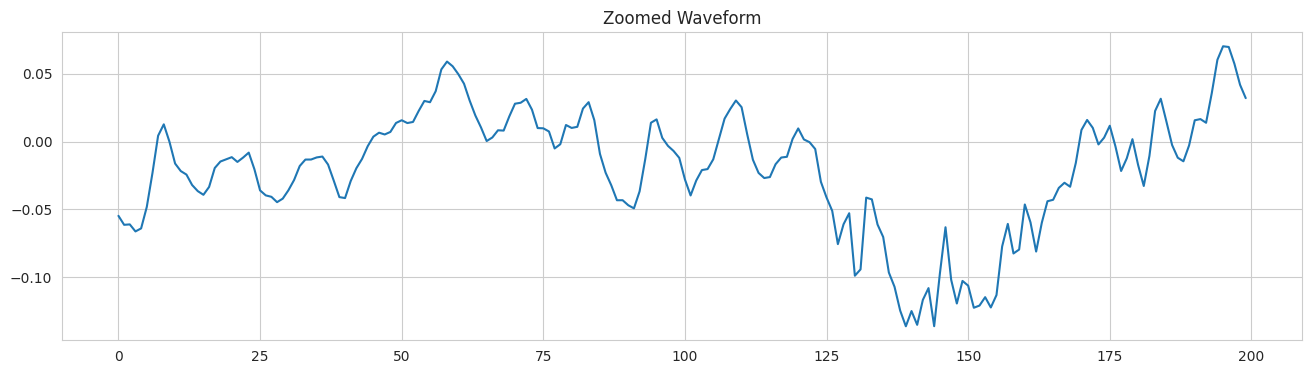

In [ ]:
# --- ZOOMED WAVE ---
start = 1000
end = 1200
plt.figure(figsize=(16,4))
plt.plot(audio_data[start:end])
plt.title("Zoomed Waveform")
plt.show()

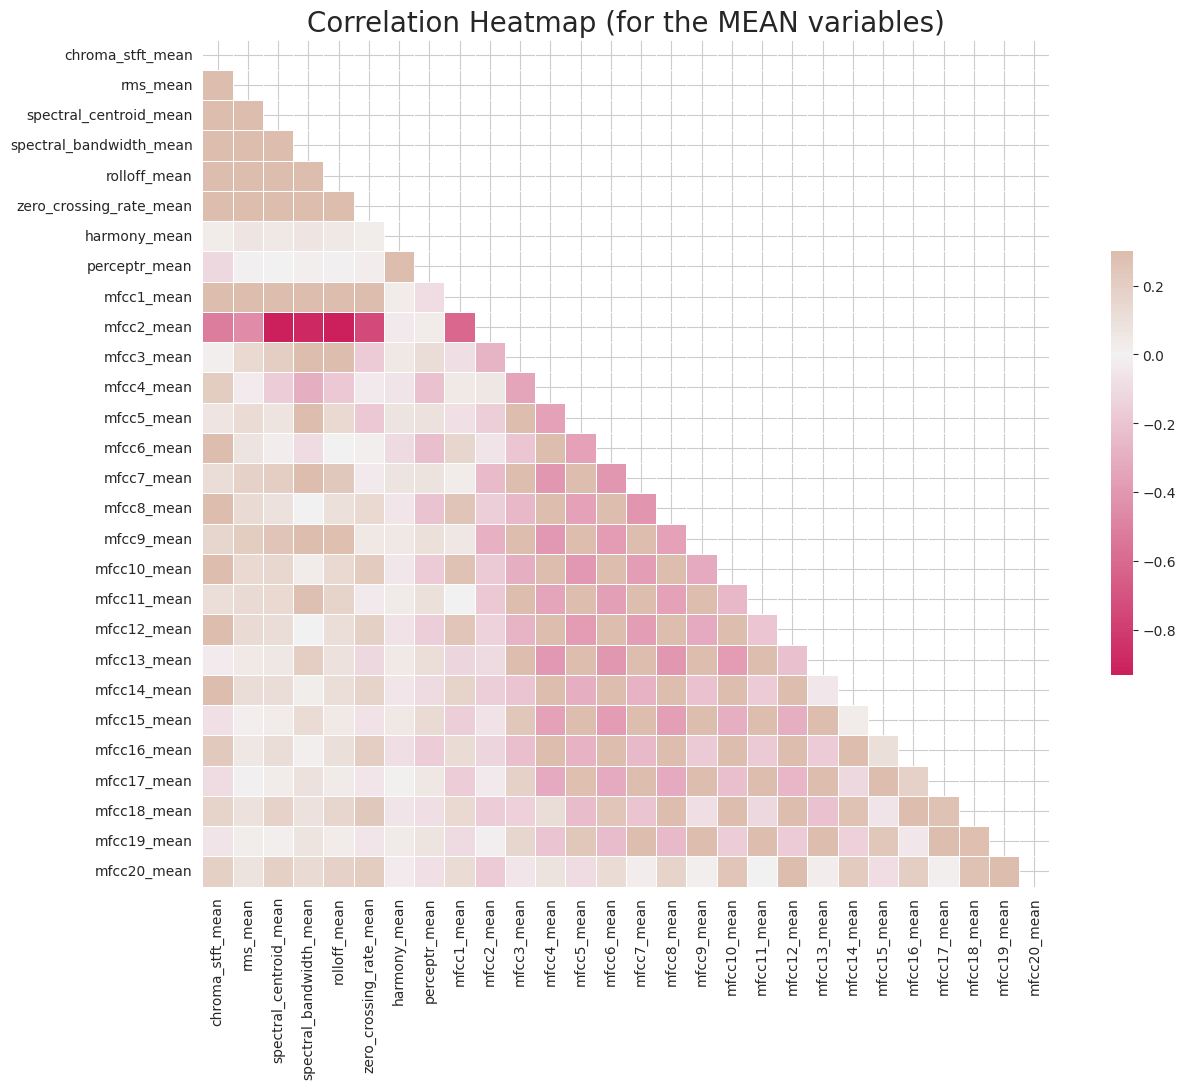

In [ ]:
# --- CORRELATION HEATMAP ---
spike_cols = [col for col in df.columns if 'mean' in col]
corr = df[spike_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(16, 11))
cmap = sns.diverging_palette(0, 25, as_cmap=True, s=90, l=45, n=5)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap (for the MEAN variables)', fontsize=20)
plt.savefig("Corr_Heatmap.png")
plt.show()

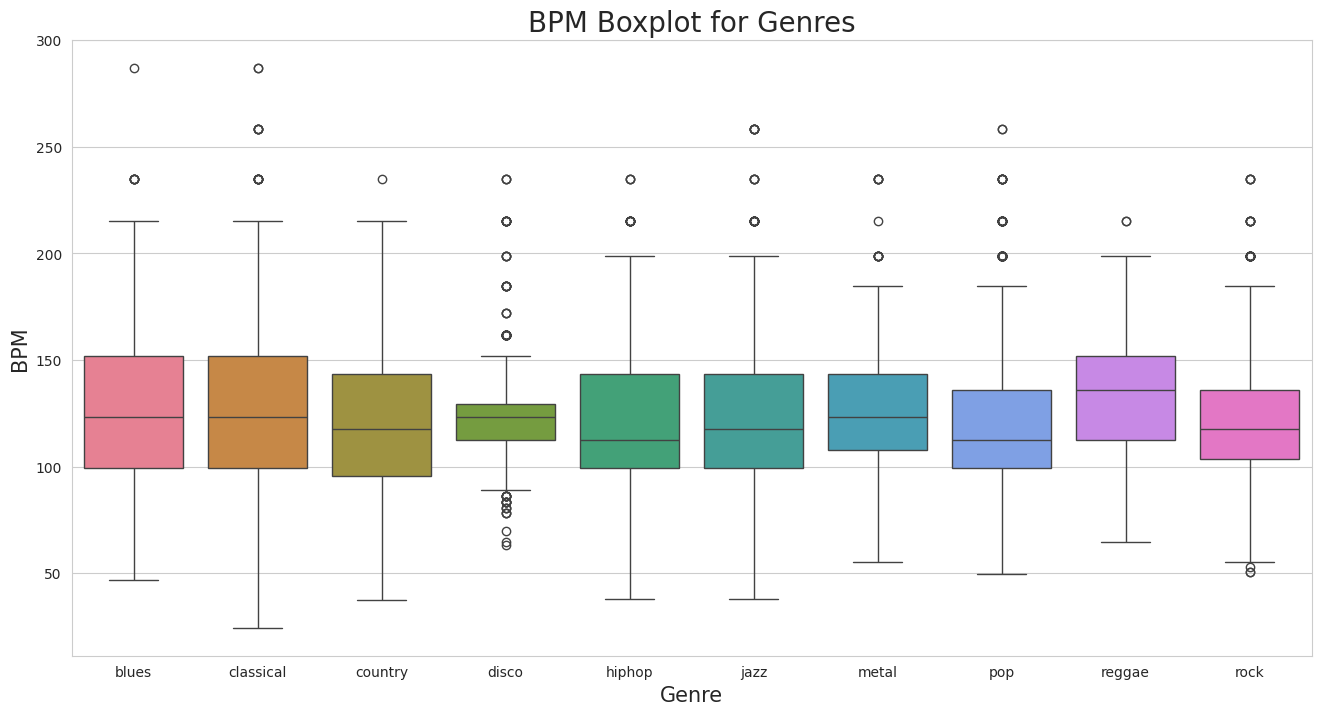

In [ ]:
# --- BOX PLOT ---
x = df[["label", "tempo"]]
fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(x="label", y="tempo", data=x, palette='husl')
plt.title('BPM Boxplot for Genres', fontsize=20)
plt.xlabel("Genre", fontsize=15)
plt.ylabel("BPM", fontsize=15)
plt.savefig("BPM_Boxplot.png")
plt.show()

In [ ]:
# --- LABEL MAPS ---
label_index = {x: i for i, x in enumerate(df.label.unique())}
index_label = {i: x for x, i in label_index.items()}

print("Label to Index Map:\n", label_index)
print("Index to Label Map:\n", index_label)

Label to Index Map:
 {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
Index to Label Map:
 {0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}


Data prep and scaling


In [ ]:
# --- ENCODE LABELS USING THE MAPPING ---
df.label = [label_index[l] for l in df.label]

In [ ]:
# --- SHUFFLE DATA ---
df_shuffle = df.sample(frac=1, random_state=seed).reset_index(drop=True)

# --- REMOVE IRRELEVANT COLUMNS ---
df_shuffle.drop(['filename', 'length'], axis=1, inplace=True, errors='ignore')

# --- SPLIT INTO FEATURES & LABELS ---
df_y = df_shuffle.pop('label')
df_X = df_shuffle

In [ ]:
# --- TRAIN/DEV/TEST SPLIT ---
X_train, df_test_valid_X, y_train, df_test_valid_y = skms.train_test_split(
    df_X, df_y,
    train_size=0.7,
    random_state=seed,
    stratify=df_y
)

X_dev, X_test, y_dev, y_test = skms.train_test_split(
    df_test_valid_X, df_test_valid_y,
    train_size=0.66,
    random_state=seed,
    stratify=df_test_valid_y
)

print(f"✅ Train set: {X_train.shape[0]} samples ({round(X_train.shape[0]/len(df_shuffle)*100)}%)")
print(f"✅ Dev set:   {X_dev.shape[0]} samples ({round(X_dev.shape[0]/len(df_shuffle)*100)}%)")
print(f"✅ Test set:  {X_test.shape[0]} samples ({round(X_test.shape[0]/len(df_shuffle)*100)}%)")


✅ Train set: 6993 samples (70%)
✅ Dev set:   1978 samples (20%)
✅ Test set:  1019 samples (10%)


In [ ]:
# --- FEATURE SCALING ---
scaler = skp.StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_dev   = pd.DataFrame(scaler.transform(X_dev), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

print("🎯 Features scaled successfully!")

🎯 Features scaled successfully!


In [ ]:
# --- MODEL TRAINING WITH KERAS ---
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
import keras as k
tf.random.set_seed(seed)

# --- ACCURACY CALLBACK ---
ACCURACY_THRESHOLD = 0.94

class myCallback(k.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs and logs.get('val_accuracy') is not None:
            if logs.get('val_accuracy') > ACCURACY_THRESHOLD:
                print(f"\n\n🎉 Stopping training! Validation accuracy reached {ACCURACY_THRESHOLD*100:.2f}%")
                self.model.stop_training = True

TensorFlow version: 2.19.0


In [ ]:
# --- TRAIN FUNCTION ---
def trainModel(model, epochs, optimizer):
    batch_size = 128
    callback = myCallback()
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[callback],
        verbose=1
    )

In [ ]:
# --- PLOT HISTORY FUNCTION ---
def plotHistory(history):
    print("📊 Max Validation Accuracy:", max(history.history["val_accuracy"]))
    pd.DataFrame(history.history).plot(figsize=(12,6))
    plt.title("Training vs Validation Accuracy/Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,650 (221.29 KB)

 Trainable params: 56,650 (221.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3822 - loss: 1.7544 - val_accuracy: 0.6411 - val_loss: 1.0193
Epoch 2/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6906 - loss: 0.9190 - val_accuracy: 0.7214 - val_loss: 0.7991
Epoch 3/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7625 - loss: 0.7099 - val_accuracy: 0.7538 - val_loss: 0.7000
Epoch 4/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8021 - loss: 0.5898 - val_accuracy: 0.7730 - val_loss: 0.6377
Epoch 5/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8370 - loss: 0.5027 - val_accuracy: 0.7851 - val_loss: 0.6023
Epoch 6/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8583 - loss: 0.4361 - val_accuracy: 0.8049 - val_loss: 0.5681
Epoch 7/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8813 - loss: 0.3773 - val_accuracy: 0.8145 - val_loss: 0.5409
Epoch 8/9
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8968 - loss: 0.3266 - val_accuracy: 0.8276 - val_loss: 0

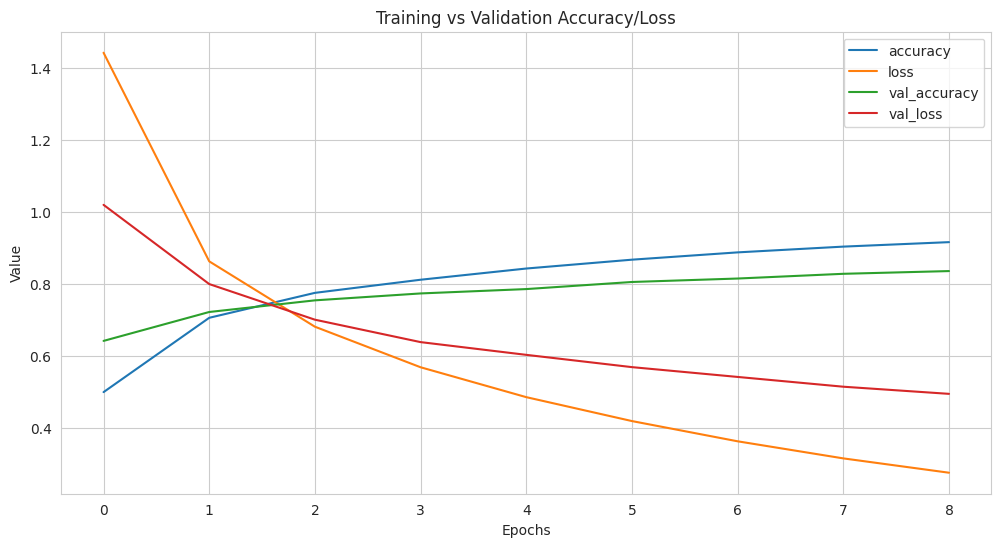

In [ ]:
# ======================================================
# 🧩 MODEL 1 — Simple Dense Layers
# ======================================================
model_1 = k.models.Sequential([
    k.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dense(128, activation='relu'),
    k.layers.Dense(64, activation='relu'),
    k.layers.Dense(10, activation='softmax'),
])
model_1.summary()

model_1_history = trainModel(model=model_1, epochs=9, optimizer='adam')
plotHistory(model_1_history)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2907 - loss: 1.9622 - val_accuracy: 0.6072 - val_loss: 1.1531
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5746 - loss: 1.2211 - val_accuracy: 0.7027 - val_loss: 0.8597
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6768 - loss: 0.9701 - val_accuracy: 0.7523 - val_loss: 0.7183
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7250 - loss: 0.8258 - val_accuracy: 0.7791 - val_loss: 0.6456
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7621 - loss: 0.6967 - val_accuracy: 0.8008 - val_loss: 0.5827
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7802 - loss: 0.6522 - val_accuracy: 0.8150 - val_loss: 0.5378
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8017 - loss: 0.5724 - val_accuracy: 0.8402 - val_loss: 0.4978
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8265 - loss: 0.5209 - val_accuracy: 0.8488 - v

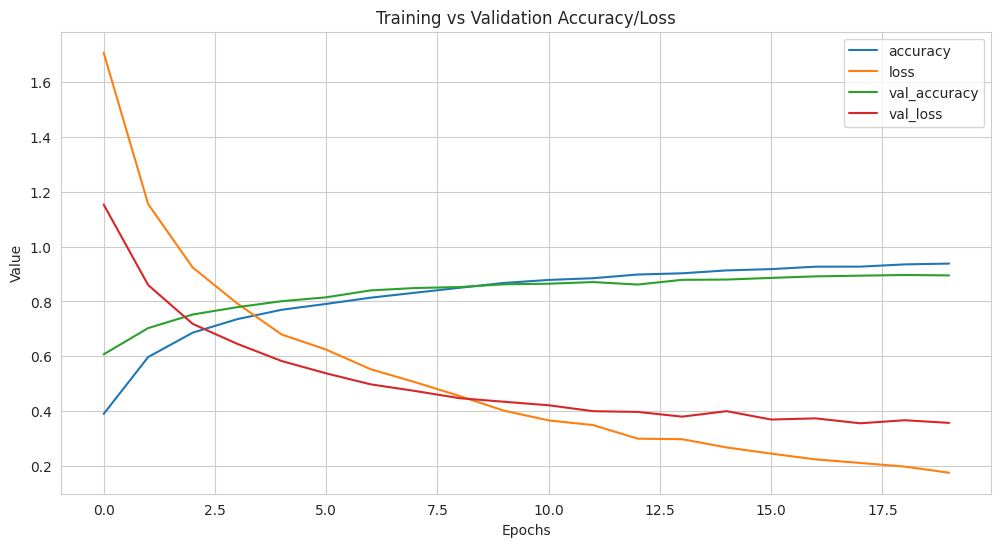

In [ ]:
# ======================================================
# 🧩 MODEL 2 — With Dropouts
# ======================================================
model_2 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
model_2.summary()

model_2_history = trainModel(model=model_2, epochs=20, optimizer='adam')
plotHistory(model_2_history)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1145 - loss: 2.3167 - val_accuracy: 0.2730 - val_loss: 2.1905
Epoch 2/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2059 - loss: 2.2120 - val_accuracy: 0.3327 - val_loss: 2.0787
Epoch 3/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2736 - loss: 2.1052 - val_accuracy: 0.3488 - val_loss: 1.9372
Epoch 4/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3183 - loss: 1.9789 - val_accuracy: 0.3615 - val_loss: 1.7907
Epoch 5/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3439 - loss: 1.8480 - val_accuracy: 0.3888 - val_loss: 1.6716
Epoch 6/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3622 - loss: 1.7516 - val_accuracy: 0.4206 - val_loss: 1.5775
Epoch 7/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4005 - loss: 1.6847 - val_accuracy: 0.4596 - val_loss: 1.5030
Epoch 8/290
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4112 - loss: 1.6188 - val_accuracy: 0.

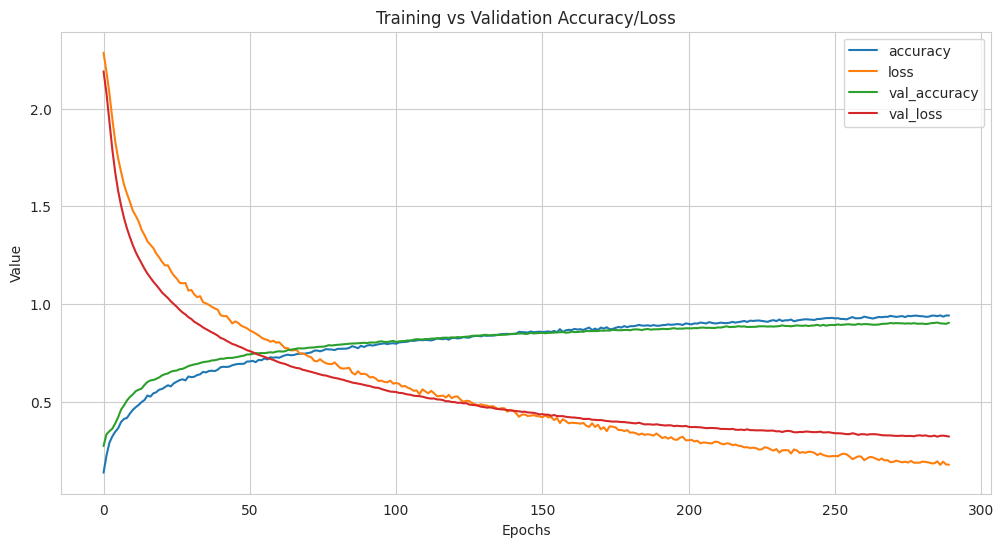

In [ ]:
# ======================================================
# 🧩 MODEL 3 — Same Architecture, SGD Optimizer
# ======================================================
model_3 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
model_3.summary()

model_3_history = trainModel(model=model_3, epochs=290, optimizer='sgd')
plotHistory(model_3_history)

In [ ]:
# ======================================================
# ✅ MODEL EVALUATION
# ======================================================
test_loss, test_acc = model_3.evaluate(X_test, y_test, batch_size=128)
print("\n🎯 Final Test Loss:", test_loss)
print("🏆 Final Test Accuracy:", test_acc * 100, "%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8896 - loss: 0.3341

🎯 Final Test Loss: 0.3477337956428528
🏆 Final Test Accuracy: 88.81255984306335 %


In [ ]:
import librosa
import librosa.display
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- CREATE SPECTROGRAM FUNCTION ---
def create_spectrogram(file_path, img_size=(128, 128), augment=False):
    try:
        # Load only the first 30 seconds for consistency
        y, sr = librosa.load(file_path, duration=30)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize to [0, 1]
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
        mel_spec_db = tf.image.resize(mel_spec_db[..., np.newaxis], img_size).numpy().squeeze()

        # Optional Augmentation (mild)
        if augment:
            if np.random.rand() > 0.5:
                # Time masking
                max_mask = int(mel_spec_db.shape[1] * 0.05)
                t_start = np.random.randint(0, mel_spec_db.shape[1] - max_mask)
                mel_spec_db[:, t_start:t_start + max_mask] = 0
            if np.random.rand() > 0.5:
                # Frequency masking
                max_mask = int(mel_spec_db.shape[0] * 0.05)
                f_start = np.random.randint(0, mel_spec_db.shape[0] - max_mask)
                mel_spec_db[f_start:f_start + max_mask, :] = 0

        return mel_spec_db
    except Exception as e:
        print(f"⚠️ Error processing {file_path}: {e}")
        return None

In [ ]:
# --- LOAD DATA ---
data_path = os.path.join(extract_path, 'Data', 'genres_original')
genres = sorted(os.listdir(data_path))
label_index = {genre: i for i, genre in enumerate(genres)}

data, labels = [], []
img_size = (128, 128)

for genre in genres:
    genre_path = os.path.join(data_path, genre)
    for file in os.listdir(genre_path):
        if file.endswith('.wav'):
            file_path = os.path.join(genre_path, file)
            # Call the modified create_spectrogram function
            spec = create_spectrogram(file_path, img_size, augment=True)
            if spec is not None:
                data.append(spec)
                labels.append(genre)

X_cnn = np.array(data) # Remove the extra dimension here
y_cnn = np.array([label_index[l] for l in labels])

print(f"✅ Loaded {len(X_cnn)} samples from {len(genres)} genres.")

⚠️ Error processing /content/GTZAN/Data/genres_original/jazz/jazz.00054.wav: 
✅ Loaded 999 samples from 10 genres.


In [ ]:
# --- CONVERT TO ARRAYS ---
X_cnn = np.array(data)[..., np.newaxis]  # Add channel dimension
y_cnn = np.array([label_index[l] for l in labels])  # Reuse label_index

print(f"X_cnn shape: {X_cnn.shape}")
print(f"y_cnn shape: {y_cnn.shape}")

# --- TRAIN/DEV/TEST SPLIT ---
X_train_cnn, X_test_valid_cnn, y_train_cnn, y_test_valid_cnn = train_test_split(
    X_cnn, y_cnn,
    train_size=0.7,
    random_state=42,
    stratify=y_cnn
)

X_dev_cnn, X_test_cnn, y_dev_cnn, y_test_cnn = train_test_split(
    X_test_valid_cnn, y_test_valid_cnn,
    train_size=0.66,
    random_state=42,
    stratify=y_test_valid_cnn
)

print(f"\nTrain: {X_train_cnn.shape[0]}, Dev: {X_dev_cnn.shape[0]}, Test: {X_test_cnn.shape[0]}")
print(f"CNN Train set: {X_train_cnn.shape[0]} samples")
print(f"CNN Dev set: {X_dev_cnn.shape[0]} samples")
print(f"CNN Test set: {X_test_cnn.shape[0]} samples")


X_cnn shape: (999, 128, 128, 1)
y_cnn shape: (999,)

Train: 699, Dev: 198, Test: 102
CNN Train set: 699 samples
CNN Dev set: 198 samples
CNN Test set: 102 samples


In [ ]:
# --- SETUP & EXTRACT DATASET ---
from google.colab import drive
import os, zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/DATASET/GTZAN/Dataset.zip'
extract_path = '/content/GTZAN'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully!")
else:
    print("📂 Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Dataset already extracted.


In [ ]:
# --- IMPORTS ---
import librosa, librosa.display
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

In [ ]:
# --- SPECTROGRAM GENERATION ---
def create_spectrogram(file_path, img_size=(128, 128), augment=False):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize [0,1]
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
        mel_spec_db = tf.image.resize(mel_spec_db[..., np.newaxis], img_size).numpy().squeeze()

        if augment:
            # Gentle augmentation
            if np.random.rand() > 0.5:
                t_mask = int(mel_spec_db.shape[1] * 0.05)
                t_start = np.random.randint(0, mel_spec_db.shape[1] - t_mask)
                mel_spec_db[:, t_start:t_start + t_mask] = 0

            if np.random.rand() > 0.5:
                f_mask = int(mel_spec_db.shape[0] * 0.05)
                f_start = np.random.randint(0, mel_spec_db.shape[0] - f_mask)
                mel_spec_db[f_start:f_start + f_mask, :] = 0

        return mel_spec_db
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:
# --- LOAD DATA ---
data_path = os.path.join(extract_path, 'Data', 'genres_original')
genres = sorted(os.listdir(data_path))
label_index = {genre: i for i, genre in enumerate(genres)}

data, labels = [], []
img_size = (128, 128)

for genre in genres:
    genre_path = os.path.join(data_path, genre)
    for file in os.listdir(genre_path):
        if file.endswith('.wav'):
            file_path = os.path.join(genre_path, file)
            # Call the modified create_spectrogram function
            spec = create_spectrogram(file_path, img_size, augment=True)
            if spec is not None:
                data.append(spec)
                labels.append(genre)

X_cnn = np.array(data) # Remove the extra dimension here
y_cnn = np.array([label_index[l] for l in labels])

print(f"✅ Loaded {len(X_cnn)} samples from {len(genres)} genres.")

Error processing /content/GTZAN/Data/genres_original/jazz/jazz.00054.wav: 
✅ Loaded 999 samples from 10 genres.


In [ ]:
# --- TRAIN / TEST SPLIT ---
X_train_cnn, X_test_valid_cnn, y_train_cnn, y_test_valid_cnn = train_test_split(
    X_cnn, y_cnn, train_size=0.7, random_state=42, stratify=y_cnn
)
X_dev_cnn, X_test_cnn, y_dev_cnn, y_test_cnn = train_test_split(
    X_test_valid_cnn, y_test_valid_cnn, train_size=0.66, random_state=42, stratify=y_test_valid_cnn
)

In [ ]:
# --- CNN MODEL ---
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,662,794 (6.34 MB)

 Trainable params: 1,662,794 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- TRAIN MODEL ---
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_dev_cnn, y_dev_cnn),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 990ms/step - accuracy: 0.0792 - loss: 2.3184 - val_accuracy: 0.1010 - val_loss: 2.2940
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.1187 - loss: 2.2863 - val_accuracy: 0.1061 - val_loss: 2.2807
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 970ms/step - accuracy: 0.1570 - loss: 2.2714 - val_accuracy: 0.2071 - val_loss: 2.2622
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 974ms/step - accuracy: 0.1619 - loss: 2.2483 - val_accuracy: 0.2576 - val_loss: 2.2176
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 961ms/step - accuracy: 0.2145 - loss: 2.2147 - val_accuracy: 0.2323 - val_loss: 2.1597
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2612 - loss: 2.1324 - val_accuracy: 0.2374 - val_loss: 2.0776
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2618 - loss: 2.0662 - val_accuracy: 0.2626 - val_loss: 2.0125
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2781 - loss: 1.9905 - val_accuracy: 0.2879

In [ ]:
# --- EVALUATE MODEL ---
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_cnn)
print(f"🎯 Improved CNN Test Accuracy: {test_acc_cnn*100:.2f}%")

y_pred_cnn = cnn_model.predict(X_test_cnn).argmax(axis=1)

print("CNN Classification Report:")
print(classification_report(y_test_cnn, y_pred_cnn, target_names=label_index.keys()))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.5321 - loss: 1.4598
🎯 Improved CNN Test Accuracy: 54.90%
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step
CNN Classification Report:
              precision    recall  f1-score   support

       blues       0.36      0.40      0.38        10
   classical       0.62      1.00      0.77        10
     country       0.50      0.70      0.58        10
       disco       0.20      0.09      0.12        11
      hiphop       0.80      0.40      0.53        10
        jazz       0.50      0.40      0.44        10
       metal       0.91      0.91      0.91        11
         pop       0.64      0.70      0.67        10
      reggae       0.67      0.60      0.63        10
        rock       0.25      0.30      0.27        10

    accuracy                           0.55       102
   macro avg       0.55      0.55      0.53       102
weighted avg       0.55      0.55      0.53       102



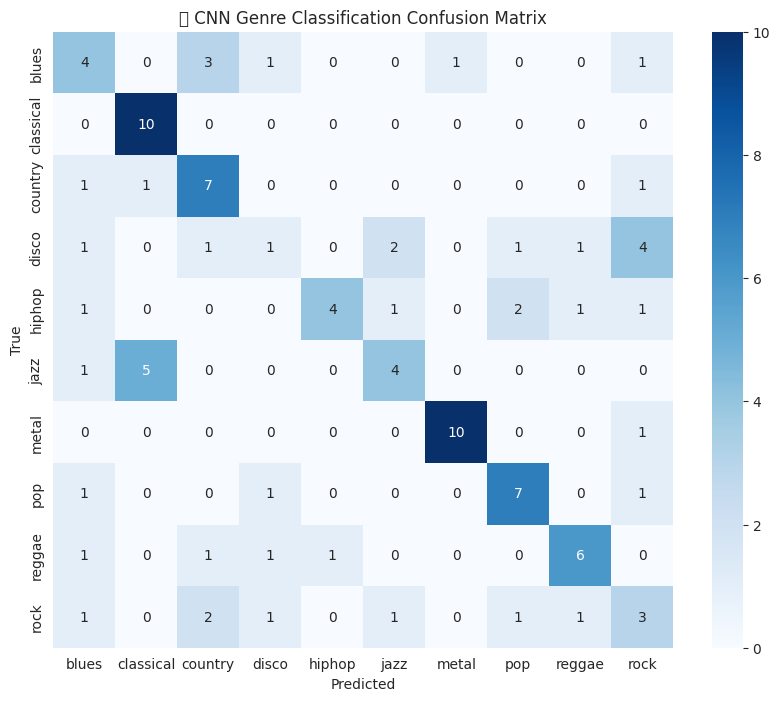

In [ ]:
# --- CONFUSION MATRIX ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_cnn, y_pred_cnn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_index.keys(), yticklabels=label_index.keys())
plt.title("🎵 CNN Genre Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# =========================================================
# 🎵 MODEL COMPARISON AND PERFORMANCE REPORT
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.facecolor'] = 'white'
sns.set_palette("husl")

In [ ]:
# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------
y_pred_model_4 = model_3.predict(X_test, batch_size=128).argmax(axis=1)
y_pred_cnn = cnn_model.predict(X_test_cnn).argmax(axis=1)

genres = list(label_index.keys())

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


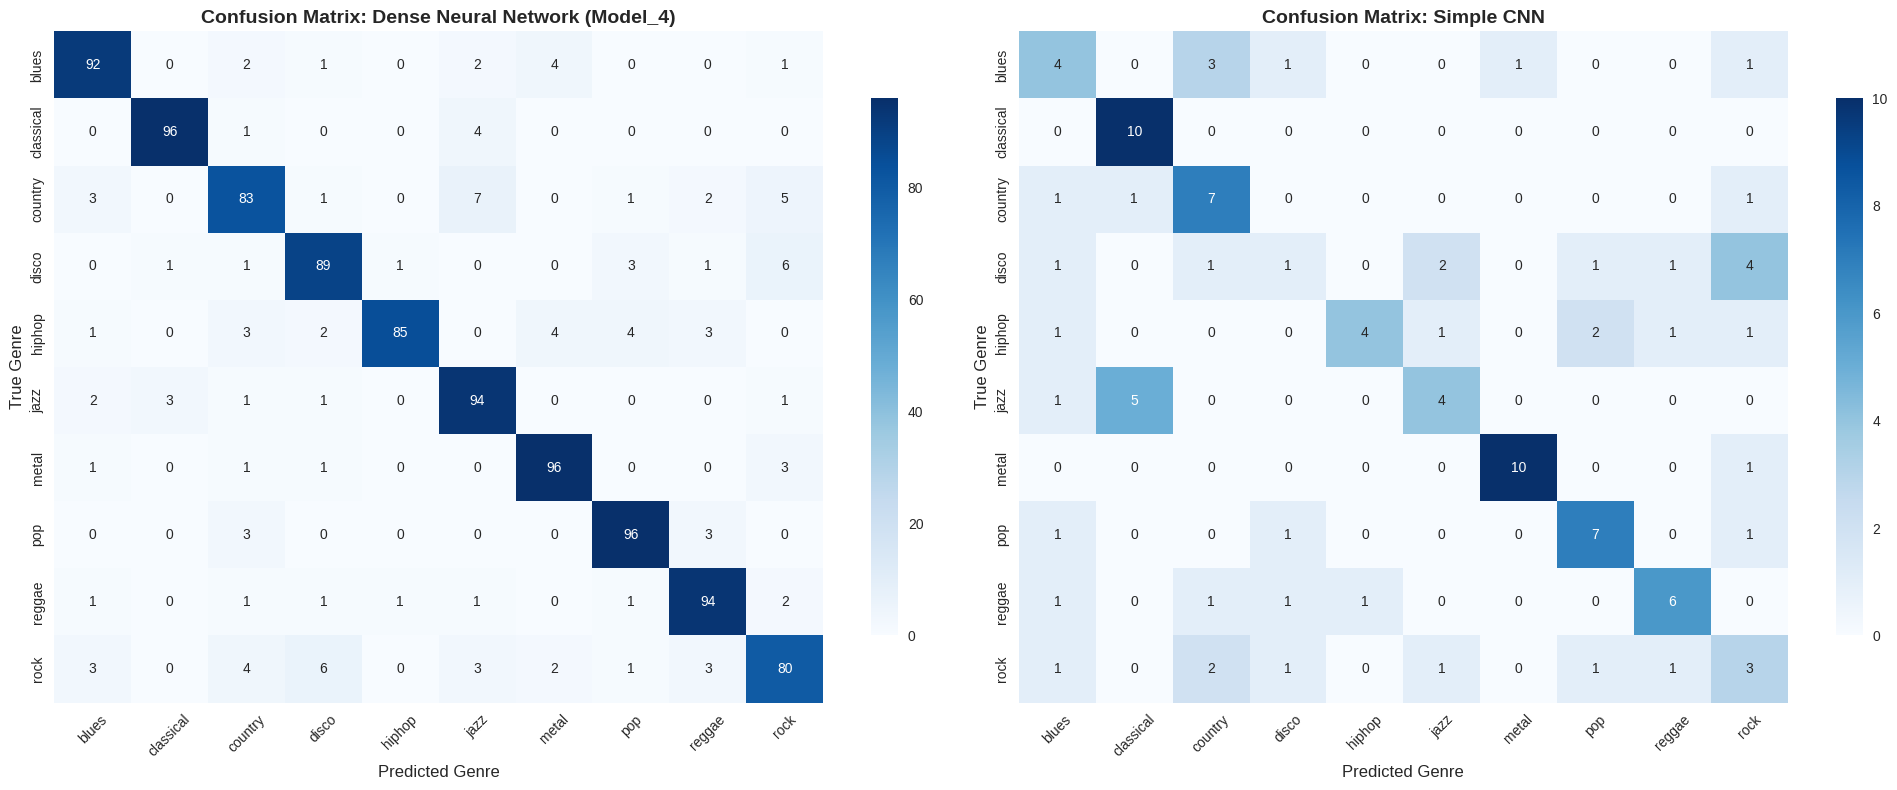

In [ ]:
# ---------------------------------------------------------
# Confusion Matrices
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
models_data = [
    ("Dense Neural Network (Model_4)", y_test, y_pred_model_4),
    ("Simple CNN", y_test_cnn, y_pred_cnn)
]

for idx, (name, y_true, y_pred) in enumerate(models_data):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=genres, yticklabels=genres,
                ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Genre', fontsize=12)
    axes[idx].set_ylabel('True Genre', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

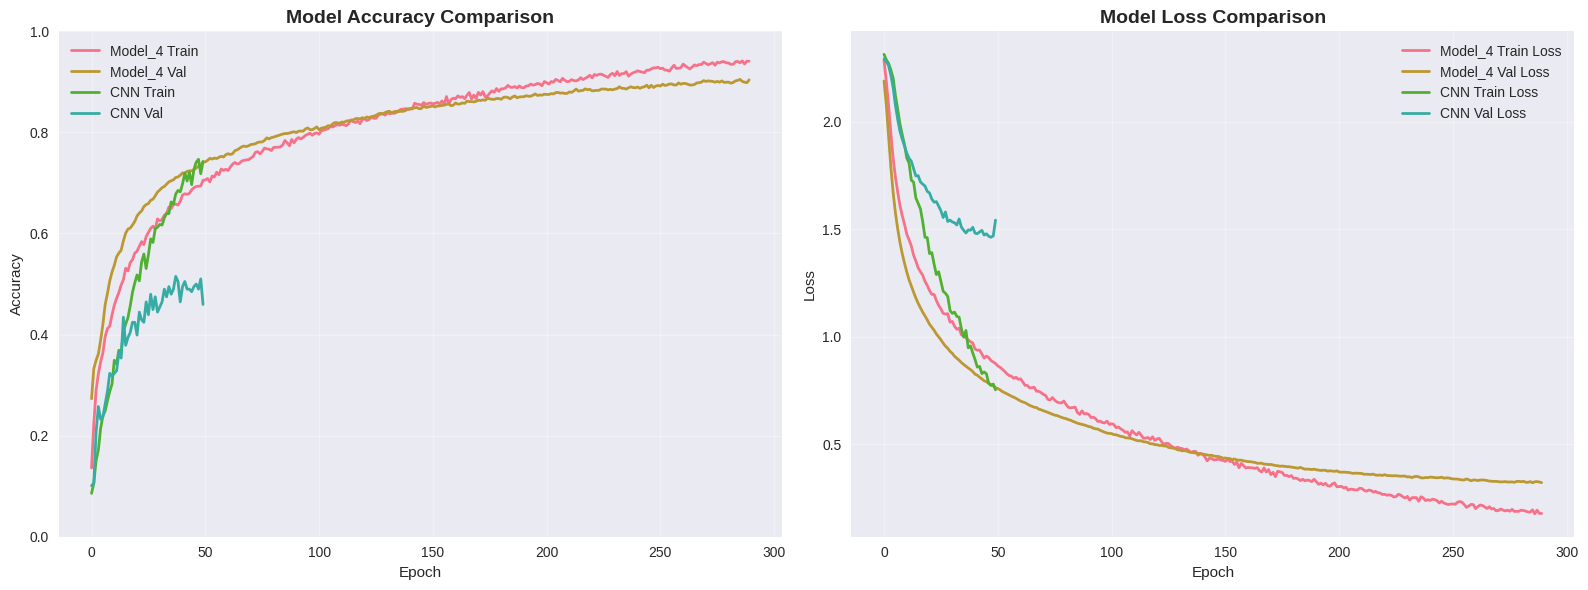

In [ ]:
# ---------------------------------------------------------
# Accuracy and Loss Curves
# ---------------------------------------------------------
history_df_model_4 = pd.DataFrame(model_3_history.history)
history_df_cnn = pd.DataFrame(cnn_history.history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Accuracy
ax1.plot(history_df_model_4['accuracy'], label='Model_4 Train', linewidth=2)
ax1.plot(history_df_model_4['val_accuracy'], label='Model_4 Val', linewidth=2)
ax1.plot(history_df_cnn['accuracy'], label='CNN Train', linewidth=2)
ax1.plot(history_df_cnn['val_accuracy'], label='CNN Val', linewidth=2)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1)

# Loss
ax2.plot(history_df_model_4['loss'], label='Model_4 Train Loss', linewidth=2)
ax2.plot(history_df_model_4['val_loss'], label='Model_4 Val Loss', linewidth=2)
ax2.plot(history_df_cnn['loss'], label='CNN Train Loss', linewidth=2)
ax2.plot(history_df_cnn['val_loss'], label='CNN Val Loss', linewidth=2)
ax2.set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Summary Stats
# ---------------------------------------------------------
print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Dense Neural Network (Model_4) Test Accuracy: {test_acc*100:.2f}%")
print(f"Simple CNN Test Accuracy: {test_acc_cnn*100:.2f}%\n")

MODEL PERFORMANCE SUMMARY
Dense Neural Network (Model_4) Test Accuracy: 88.81%
Simple CNN Test Accuracy: 54.90%



In [ ]:
# Classification Reports
for name, y_true, y_pred in models_data:
    print(f"\nClassification Report - {name}")
    print("-" * 50)
    print(classification_report(y_true, y_pred, target_names=genres, digits=3))


Classification Report - Dense Neural Network (Model_4)
--------------------------------------------------
              precision    recall  f1-score   support

       blues      0.893     0.902     0.898       102
   classical      0.960     0.950     0.955       101
     country      0.830     0.814     0.822       102
       disco      0.873     0.873     0.873       102
      hiphop      0.977     0.833     0.899       102
        jazz      0.847     0.922     0.883       102
       metal      0.906     0.941     0.923       102
         pop      0.906     0.941     0.923       102
      reggae      0.887     0.922     0.904       102
        rock      0.816     0.784     0.800       102

    accuracy                          0.888      1019
   macro avg      0.889     0.888     0.888      1019
weighted avg      0.889     0.888     0.888      1019


Classification Report - Simple CNN
--------------------------------------------------
              precision    recall  f1-score   s

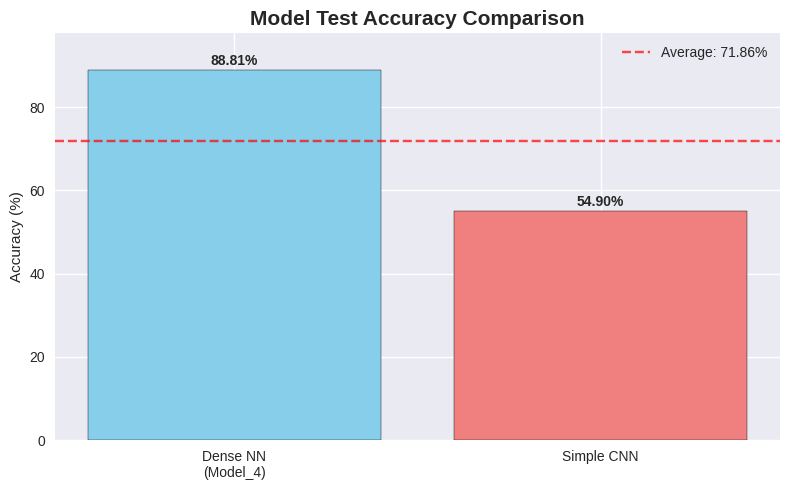

In [ ]:
# ---------------------------------------------------------
# Accuracy Bar Chart
# ---------------------------------------------------------
model_names = ['Dense NN\n(Model_4)', 'Simple CNN']
accuracies = [test_acc * 100, test_acc_cnn * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral'], edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.title('Model Test Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, max(accuracies) * 1.1)
plt.axhline(np.mean(accuracies), color='red', linestyle='--', alpha=0.7,
            label=f'Average: {np.mean(accuracies):.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Per-class Accuracy
# ---------------------------------------------------------
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*60)
for name, y_true, y_pred in models_data:
    print(f"\n{name}:")
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    for genre, acc in zip(genres, per_class_acc):
        print(f"{genre:15}: {acc:6.2f}%")


PER-CLASS PERFORMANCE ANALYSIS

Dense Neural Network (Model_4):
blues          :  90.20%
classical      :  95.05%
country        :  81.37%
disco          :  87.25%
hiphop         :  83.33%
jazz           :  92.16%
metal          :  94.12%
pop            :  94.12%
reggae         :  92.16%
rock           :  78.43%

Simple CNN:
blues          :  40.00%
classical      : 100.00%
country        :  70.00%
disco          :   9.09%
hiphop         :  40.00%
jazz           :  40.00%
metal          :  90.91%
pop            :  70.00%
reggae         :  60.00%
rock           :  30.00%


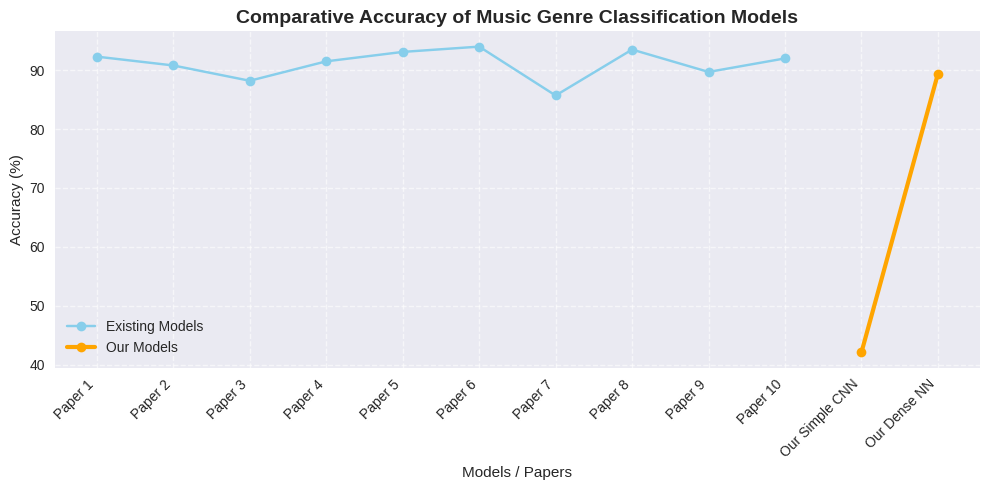

In [ ]:
import matplotlib.pyplot as plt

# Paper names (shortened for readability)
papers = [
    "Paper 1", "Paper 2", "Paper 3", "Paper 4", "Paper 5",
    "Paper 6", "Paper 7", "Paper 8", "Paper 9", "Paper 10",
    "Our Simple CNN", "Our Dense NN"
]

# Accuracy values
accuracies = [92.3, 90.8, 88.2, 91.5, 93.1, 94.0, 85.7, 93.5, 89.7, 92.0, 42.1, 89.4]

# Highlight your models differently
plt.figure(figsize=(10,5))
plt.plot(papers[:-2], accuracies[:-2], marker='o', label='Existing Models', color='skyblue')
plt.plot(papers[-2:], accuracies[-2:], marker='o', label='Our Models', color='orange', linewidth=3)

plt.title('Comparative Accuracy of Music Genre Classification Models', fontsize=14, fontweight='bold')
plt.xlabel('Models / Papers')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

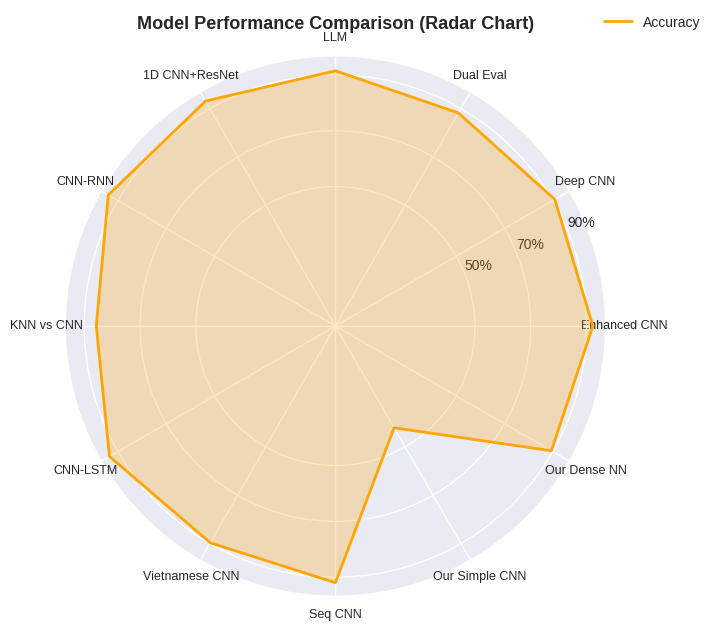

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Labels and values
labels = [
    "Enhanced CNN", "Deep CNN", "Dual Eval", "LLM", "1D CNN+ResNet",
    "CNN-RNN", "KNN vs CNN", "CNN-LSTM", "Vietnamese CNN", "Seq CNN",
    "Our Simple CNN", "Our Dense NN"
]
values = [92.3, 90.8, 88.2, 91.5, 93.1, 94.0, 85.7, 93.5, 89.7, 92.0, 42.1, 89.4]

# Setup radar
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='orange', linewidth=2, linestyle='solid', label='Accuracy')
ax.fill(angles, values, color='orange', alpha=0.25)

ax.set_yticks([50, 70, 90])
ax.set_yticklabels(['50%', '70%', '90%'])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_title("Model Performance Comparison (Radar Chart)", fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()

In [ ]:
import librosa
import numpy as np

def extract_features(file_path, max_pad_len=174):
    try:
        audio, sr = librosa.load(file_path, duration=30, mono=True, sr=22050)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Padding or truncating
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc
    except Exception as e:
        print("Error encountered while parsing file: ", file_path)
        return None

In [ ]:
cnn_model.input_shape

X_input = np.expand_dims(spec, axis=(0, -1))

# spec = np.stack((spec,)*3, axis=-1)   # convert grayscale → RGB
X_input = np.expand_dims(spec, axis=(0, -1))

print("Spec shape before expand:", spec.shape)
print("Model expects:", cnn_model.input_shape)
print("Shape of X_input before prediction:", X_input.shape)

Spec shape before expand: (128, 128)
Model expects: (None, 128, 128, 1)
Shape of X_input before prediction: (1, 128, 128, 1)


In [ ]:
# Save the trained CNN model to Google Drive
cnn_model_save_path = '/content/drive/MyDrive/music_genre_cnn_model.h5'
cnn_model.save(cnn_model_save_path)
print(f"✅ CNN model saved successfully to: {cnn_model_save_path}")

✅ CNN model saved successfully to: /content/drive/MyDrive/music_genre_cnn_model.h5


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# 👇 Load your trained model (adjust name if saved differently)
# Construct the correct path to the saved model
model_path = '/content/drive/MyDrive/music_genre_cnn_model.h5'  # Assuming the model is saved here
cnn_model = load_model(model_path)

# 👇 Label encoder used in training (recreate same order as training dataset)
label_encoder = {
    0: 'blues',
    1: 'classical',
    2: 'country',
    3: 'disco',
    4: 'hiphop',
    5: 'jazz',
    6: 'metal',
    7: 'pop',
    8: 'reggae',
    9: 'rock'
}

# 👇 Function to preprocess input audio just like training
def preprocess_audio(file_path, img_size=(128, 128)):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=30)

        # Convert to mel-spectrogram (same as training)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize [0,1]
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())

        # Resize to the target image size
        mel_spec_db = tf.image.resize(mel_spec_db[..., np.newaxis], img_size).numpy().squeeze()

        # Add channel dimension explicitly
        mel_spec_db = np.expand_dims(mel_spec_db, axis=-1)

        # Add batch dimension
        mel_spec_db = np.expand_dims(mel_spec_db, axis=0)


        return mel_spec_db
    except Exception as e:
        print(f"⚠️ Error while processing {file_path}: {e}")
        return None

# 👇 Path to your test file
test_file = '/content/R.wav'

# 👇 Preprocess and predict
X_input = preprocess_audio(test_file)

if X_input is not None:
    pred = cnn_model.predict(X_input)
    predicted_class = np.argmax(pred, axis=1)[0]
    predicted_label = label_encoder[predicted_class]
    print("🎼 Predicted Genre:", predicted_label)
else:
    print("🚫 Could not process the input file.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
🎼 Predicted Genre: rock
